In [1]:
import torch
from score_models import NCSNpp
import sys
from torch.func import jacrev, jacfwd, vjp, vmap
from torch.autograd import grad
import numpy as np
from torch.nn import functional as F
sys.path.append("../scripts/")
from astropy.io import fits
from astropy.coordinates import SkyCoord
import h5py
from torch.func import jvp
from tqdm import tqdm
from astropy import units
from forward_model import make_forward_model, make_wcs

# Construct a rectangular circulant matrix similar to our physical model

In [57]:
def construct_dft(m):
    omega = np.exp(-2j * np.pi / m)
    F = np.zeros([m, m], dtype=np.complex64)
    for i in range(m):
        for j in range(m):
            F[i, j] = omega**((i * j) % m)
    return F / m**(1/2)

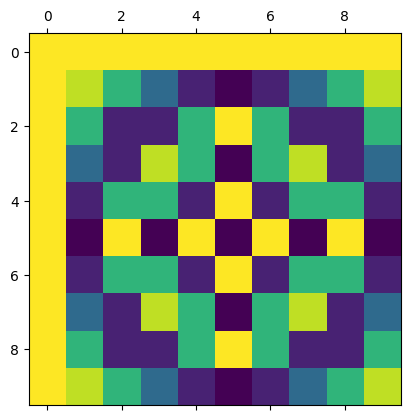

In [58]:
F = construct_dft(10)
plt.matshow(F.real)

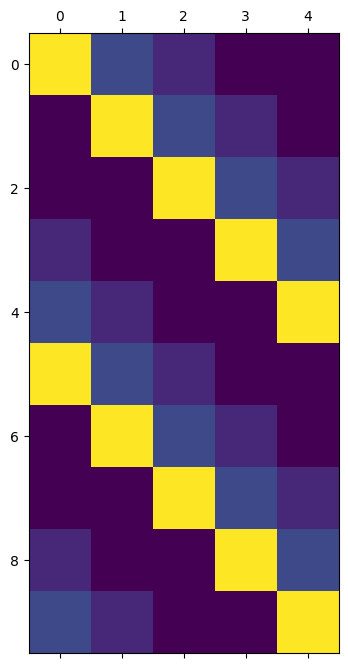

In [146]:
def construct_circulant(row, rows, columns):
    # append rows by applying a cyclic shift
    C = np.zeros([rows, columns])
    for i in range(rows):
        C[i] = np.roll(row[:columns], shift=i)
    return C

# h = np.array([1, 3, 1])
h = np.array([0, 0, 0, 1, 2, 9, 2, 1, 0, 0, 0])

m = 10
n = 5

# kernel is centered, account for this by shifting center to first element of the row 
row = np.roll(h, shift=h.size//2 + 1*(h.size%2))
C = torch.tensor(construct_circulant(row, m, n)).float()

plt.matshow(C)

# How do we diagonalize this? Can we use the Fourier transform like before?

In [147]:
A = C.numpy()

my_effective_kernel = A[:, 0] # take a row
F_left = construct_dft(m)
F_right = construct_dft(n)

my_effective_kernel_hat = F_left @ my_effective_kernel

# plt.matshow((F_left @ A).real)
# plt.colorbar()

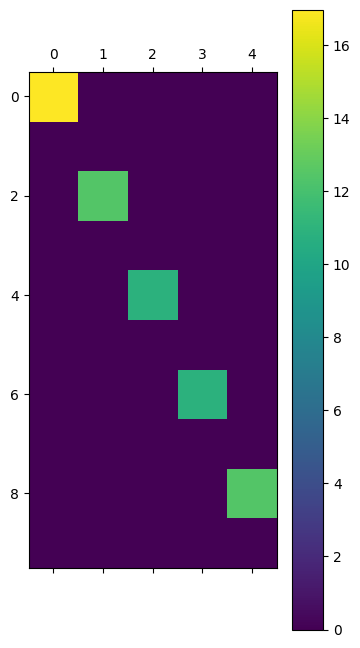

In [148]:
plt.matshow((F_left @ A @ F_right.T.conj()).real)
plt.colorbar()

In [149]:
effective_kernel = (F_left @ A @ F_right.T.conj())

# plt.matshow((F_left.T.conj() @ effective_kernel @ F_right).real)

In [150]:
np.diag(effective_kernel)**(1/2)

array([4.1195340e+00+0.0000000e+00j, 2.0948377e-04-2.1254568e-04j,
       2.0725491e-05+5.3056935e-04j, 2.3972050e-04+9.9470664e-05j,
       7.0115857e-05-4.9162225e-04j], dtype=complex64)

In [151]:
my_effective_kernel_hat

array([7.5894661e+00+0.j        , 1.1920929e-07+0.j        ,
       5.5713110e+00+1.57475j   , 5.9604645e-08+0.j        ,
       4.8642044e+00+0.14199507j, 1.4901161e-07+0.j        ,
       4.8642044e+00-0.14199507j, 5.9604645e-08+0.j        ,
       5.5713110e+00-1.57475j   , 1.1920929e-07+0.j        ],
      dtype=complex64)